# **Analyse des cannaux telegram**

In [30]:
# Installer les librairies nécessaires (à exécuter dans une cellule Jupyter ou le terminal uniquement si elles ne sont pas déjà installées)
!pip install scipy==1.12.0
!pip install nltk
!pip install gensim
!pip install scikit-learn
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install wordcloud
!pip install vaderSentiment

  Using cached wordcloud-1.9.4-cp312-cp312-win_amd64.whl.metadata (3.5 kB)
Using cached wordcloud-1.9.4-cp312-cp312-win_amd64.whl (301 kB)


In [34]:
!pip install --upgrade gensim

  Using cached gensim-4.3.3-cp312-cp312-win_amd64.whl.metadata (8.2 kB)
Using cached gensim-4.3.3-cp312-cp312-win_amd64.whl (24.0 MB)
  Attempting uninstall: gensim
    Found existing installation: gensim 4.3.2
    Uninstalling gensim-4.3.2:
      Successfully uninstalled gensim-4.3.2


In [244]:
!pip install plotly

In [5]:
from numpy import triu        #  devrait fonctionner
from scipy.sparse import triu #  aussi possible
import pandas as pd
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import json
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from gensim import corpora, models
from wordcloud import WordCloud
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


**1. Qu’est-ce que les influenceurs apportent au phénomène crypto ?**

Méthodes :
Identifier les comptes/groupes qui publient le plus de messages → volume de publication par groupe.

Voir les thématiques qu'ils mettent en avant : investissement ? éducation ? hype ?

Analyse de la temporalité : pic d’activité à certains moments (lien avec une annonce ?).

Indicateurs :
Nombre moyen de messages/jour par groupe (group_name).

Thèmes abordés par chaque groupe : créer un nuage de mots par groupe.

Si tu ajoutes les username plus tard, tu pourras repérer les auteurs les plus actifs (ici ce n’est pas possible pour le moment).

Dans le but d'analyser les pratiques des influenceurs sur les réseaux sociaux, le scrapping des publications Telegram de 6 influenceurs publiant au total 56775 message sur une Période d'analyse : 7 ans. Ces influenceurs , font parti des plus suivis sur la base du nombre de followers sur leur différents réseaux nous ont permeu de basé notre choix sur ces différents cax d'influenceurs qui se positionnent sur des thématiques différentes allant de ceux qui abordent des sujets techniques à ceux qui proposesnt des formations. Toute ces pratiques consites à vulgariser le phénomènes crypto et à conduire les gens à s'interresser aux sujets crypto. Plus ils font des publications, plus l'algorithme des diférents réseaux sur le quel il relais leur publications propose ça aux abonnées. Pour pouvooir répondre à la question de ce que les influenceurs apportent au phénomène crypto, les scrappings des comptes Telegram, va noous permettre de d'analyser les nombre de publication par ou par mois a fin devoir le dynnamisme, l'intensité des activités de ces influenceurs. Sachant qu'on est sur produit purement spéculatif, chaque publication ou chaque poste parlant de la crypto peux contribuer  à amener les gens à ss'interresser aux actifs cryptos. Donc, pour anlyser cette question on a mobiliser nos compétences en programmmation avec python, en alayse des données, en statistiques, en data visualisation, machine learning et en language naturel en utilisant des librairies comme pandas, Numpy, skeit-lear, nltk, plotly, gensim et vaderSentiment. Ces différentes techniques nous ont aidé a posé les bases du traitement des méssages, les regrouper et les staocker dans un fichier json pour es préparer à l'analyse. Et grace à l'analyse des données scrapper on a pu analyser les tendences dans les publications pour identifier la fréquesnces des publications par groupe et sur l'ensemble des 6 groupes, les pateformes ou les réseaux sociaux les plus utilisn'és. Ces différentes approches nous ont permis de répondre à la questions qu'on a posé en haut qui est Qu’est-ce que les influenceurs apportent au phénomène crypto ? Les résultats pertséinents à cette questions seront exposées dans la partie 2. 



**Analyse des influenceurs dans le domaine des cryptomonnaies**

Pour répondre à la question « Qu’est-ce que les influenceurs apportent au phénomène crypto ? », nous avons récupéré les messages publiés sur Telegram par 12 influenceurs très connus dans le domaine des cryptomonnaies. Voici la liste des comptes étudiés :

Cryptoast

Journal Du Coin

Hasheur | Owen Simonin

Futures Analysen Signals (Ai)

CoinAcademy - News

Foufi : Analyses & actualités

Julien Roman

The Cryptomath

Paul Cryptoformation

Enter The Crypto Matrix

ThibautCrypto

GLOBAL CONNECT

Ces influenceurs ont été choisis parce qu’ils sont très suivis sur les réseaux sociaux et qu’ils publient régulièrement. Ils ont des approches différentes : certains font de l’analyse technique, d’autres expliquent les bases de la crypto, ou proposent des formations. Ils participent tous à rendre le sujet plus accessible au grand public.

Nous avons collecté 56 775 messages publiés par ces comptes sur une période de 7 ans. Les messages ont été extraits sous forme de fichier JSON, avec les informations suivantes :



| Variable        | Description                                                                 |
|-----------------|-----------------------------------------------------------------------------|
| `id`            | Identifiant unique de chaque ligne/message dans la base de données.         |
| `group_id`      | Identifiant unique du groupe Telegram d’où provient le message.             |
| `group_name`    | Nom du groupe Telegram.                                                     |
| `message_id`    | Identifiant unique du message dans le groupe Telegram.                      |
| `date`          | Date et heure de publication du message.                                    |
| `sender_id`     | Identifiant unique de l’expéditeur du message.                              |
| `first_name`    | Prénom de l’expéditeur (s’il est disponible).                               |
| `last_name`     | Nom de famille de l’expéditeur (s’il est disponible).                       |
| `username`      | Pseudo Telegram de l’expéditeur (commence souvent par @).                   |
| `message`       | Contenu textuel du message publié.                                          |
| `media_type`    | Type de média associé au message (ex: `photo`, `video`, `link`, `none`).   |
| `media_path`    | Chemin d’accès local ou URL du fichier média téléchargé (si applicable).    |
| `reply_to`      | Message ID auquel celui-ci répond (s’il s’agit d’une réponse).              |
| `member_count`  | Nombre de membres du groupe au moment de l’extraction ou du message.|


L’objectif est de comprendre comment ces influenceurs participent à la diffusion de l’information sur la crypto, à travers :

Le nombre de messages postés par jour, mois ou année,

La fréquence de publication,

Les sujets abordés dans les messages,

Les types de contenus (texte, image, lien, etc.),

Les réseaux sociaux ou plateformes mentionnés.

Pour faire cette analyse, j’ai utilisé des compétences en programmation Python, en analyse de données et en traitement du langage. J’ai utilisé plusieurs librairies Python comme :

pandas et numpy pour organiser et manipuler les données,

plotly pour créer des visualisations,

nltk, gensim et vaderSentiment pour analyser les textes,

scikit-learn pour appliquer des techniques d’analyse plus avancées.

L’analyse nous permettra de voir comment les influenceurs participent à faire connaître la crypto et à attirer de nouveaux publics. Par exemple, on pourra observer si certains influenceurs publient plus que d’autres, à quels moments ils sont plus actifs, et quels types de messages ils utilisent pour capter l’attention.

Les résultats liés à cette première question seront présentés dans la partie 2 du rapport.

In [100]:
# Importation des données

# Charger les données depuis le fichier JSON
fichier_json = 'all_crypto_groups_messages.json'

with open(fichier_json, 'r', encoding='utf-8') as f:
    data = json.load(f)

# Extraire tous les messages de tous les groupes
messages = []
for groupe in data:
    for msg in groupe.get("messages", []):
        msg['group_name'] = groupe.get("group_name")
        msg['group_id'] = groupe.get("group_id")
        msg['member_count'] = groupe.get("member_count")
        messages.append(msg)

# Créer un DataFrame à partir des messages
df = pd.DataFrame(messages)




# Afficher les premières lignes du DataFrame
print(df.head())

# (Optionnel) Conversion de la date
df['date'] = pd.to_datetime(df['date'])



     id       group_id group_name  message_id                       date  \
0  None -1001173843767  Cryptoast       15919  2025-05-28 21:23:14+00:00   
1  None -1001173843767  Cryptoast       15918  2025-05-28 21:20:55+00:00   
2  None -1001173843767  Cryptoast       15916  2025-05-28 20:35:21+00:00   
3  None -1001173843767  Cryptoast       15915  2025-05-28 20:23:21+00:00   
4  None -1001173843767  Cryptoast       15914  2025-05-28 20:02:48+00:00   

   sender_id first_name last_name username  \
0        NaN       None      None     None   
1        NaN       None      None     None   
2        NaN       None      None     None   
3        NaN       None      None     None   
4        NaN       None      None     None   

                                             message         media_type  \
0  🐶 21Shares dépose une demande pour un ETF spot...               None   
1  🇵🇰 Le Pakistan va créer une réserve stratégiqu...  MessageMediaPhoto   
2  💰 VivoPower International lève 121 mil

,id,group_id,group_name,message_id,date,sender_id,first_name,last_name,username,message,media_type,media_path,reply_to,member_count
0,None,-1001173843767,Cryptoast,15919,2025-05-28 21:23:14+00:00,NaN,None,None,None,🐶 21Shares dépose une demande pour un ETF spot...,None,None,NaN,14993
1,None,-1001173843767,Cryptoast,15918,2025-05-28 21:20:55+00:00,NaN,None,None,None,🇵🇰 Le Pakistan va créer une réserve stratégiqu...,MessageMediaPhoto,None,NaN,14993
2,None,-1001173843767,Cryptoast,15916,2025-05-28 20:35:21+00:00,NaN,None,None,None,💰 VivoPower International lève 121 millions $ ...,MessageMediaPhoto,None,NaN,14993
3,None,-1001173843767,Cryptoast,15915,2025-05-28 20:23:21+00:00,NaN,None,None,None,💰 Nvidia (NVDA) annonce un chiffre d'affaires ...,None,None,NaN,14993
4,None,-1001173843767,Cryptoast,15914,2025-05-28 20:02:48+00:00,NaN,None,None,None,📉 Trump Media Group chute de 24 % après l'anno...,MessageMediaPhoto,None,NaN,14993
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56770,None,-1002530741739,GLOBAL CONNECT,20,2025-05-04 10:19:15+00:00,NaN,None,None,None,,MessageMediaPoll,None,NaN,14702
56771,None,-1002530741739,GLOBAL CONNECT,16,2025-05-02 23:22:44+00:00,NaN,None,None,None,Tu veux publier une annonce ?\n\nRemplis ce fo...,None,None,NaN,14702
56772,None,-1002530741739,GLOBAL CONNECT,14,2025-05-02 18:38:57+00:00,NaN,None,None,None,➖➖➖➖➖➖➖➖➖➖➖➖➖➖➖,None,None,NaN,14702
56773,None,-1002530741739,GLOBAL CONNECT,13,2025-05-02 18:37:23+00:00,NaN,None,None,None,⸻\nPourquoi cette idée 🤷🏼‍♂️?\n\nDans un monde...,MessageMediaPhoto,None,NaN,14702


In [108]:
len(df)
# Assure-toi que la colonne 'date' est bien au format datetime
df['date'] = pd.to_datetime(df['date'])

# Calcul de la période d'analyse en années
periode = df['date'].max().year - df['date'].min().year
print(f"Période d'analyse : {periode} ans")


Période d'analyse : 7 ans


In [138]:
# Liste des groupes telegram
canal = df['group_name'].unique()
print(canal)
canal_df = pd.DataFrame(canal)
canal_df

# Exemple : valeurs uniques de la colonne 'group_name'
canal_uniques = pd.DataFrame(df['group_name'].unique(), columns=['group_name'])

canal_uniques


['Cryptoast' 'Journal Du Coin' 'Hasheur | Owen Simonin'
 'Futures Analysen Signals (Ai)' 'CoinAcademy - News'
 'Foufi : Analyses & actualités' 'Julien Roman' 'The Cryptomath'
 'Paul Cryptoformation' 'Enter The Crypto Matrix' 'ThibautCrypto'
 'GLOBAL CONNECT']


,group_name
0,Cryptoast
1,Journal Du Coin
2,Hasheur | Owen Simonin
3,Futures Analysen Signals (Ai)
4,CoinAcademy - News
5,Foufi : Analyses & actualités
6,Julien Roman
7,The Cryptomath
8,Paul Cryptoformation
9,Enter The Crypto Matrix


In [126]:
# Le nombre de méssage par groupe
df['group_name'].value_counts()

group_name
Cryptoast                        15607
Futures Analysen Signals (Ai)    12121
Foufi : Analyses & actualités     9365
CoinAcademy - News                5108
Journal Du Coin                   3939
The Cryptomath                    3884
Enter The Crypto Matrix           2472
Paul Cryptoformation              1579
Julien Roman                      1393
Hasheur | Owen Simonin            1278
GLOBAL CONNECT                      27
ThibautCrypto                        2
Name: count, dtype: int64

In [146]:
df.columns

Index(['id', 'group_id', 'group_name', 'message_id', 'date', 'sender_id',
       'first_name', 'last_name', 'username', 'message', 'media_type',
       'media_path', 'reply_to', 'member_count'],
      dtype='object')

**Exemple 1 : Fréquence des messages par groupe**

In [61]:
# Fréquence des messages par groupe
df['date'] = pd.to_datetime(df['date'])
messages_par_jour = df.groupby(['group_name', df['date'].dt.date]).size().reset_index(name='n_messages')
print(messages_par_jour )

              group_name        date  n_messages
0     CoinAcademy - News  2021-05-03           5
1     CoinAcademy - News  2021-05-04           2
2     CoinAcademy - News  2021-05-05           3
3     CoinAcademy - News  2021-05-06           2
4     CoinAcademy - News  2021-05-07           1
...                  ...         ...         ...
8394      The Cryptomath  2025-05-26           3
8395      The Cryptomath  2025-05-27           2
8396      The Cryptomath  2025-05-28           1
8397       ThibautCrypto  2024-11-25           1
8398       ThibautCrypto  2025-05-19           1

[8399 rows x 3 columns]


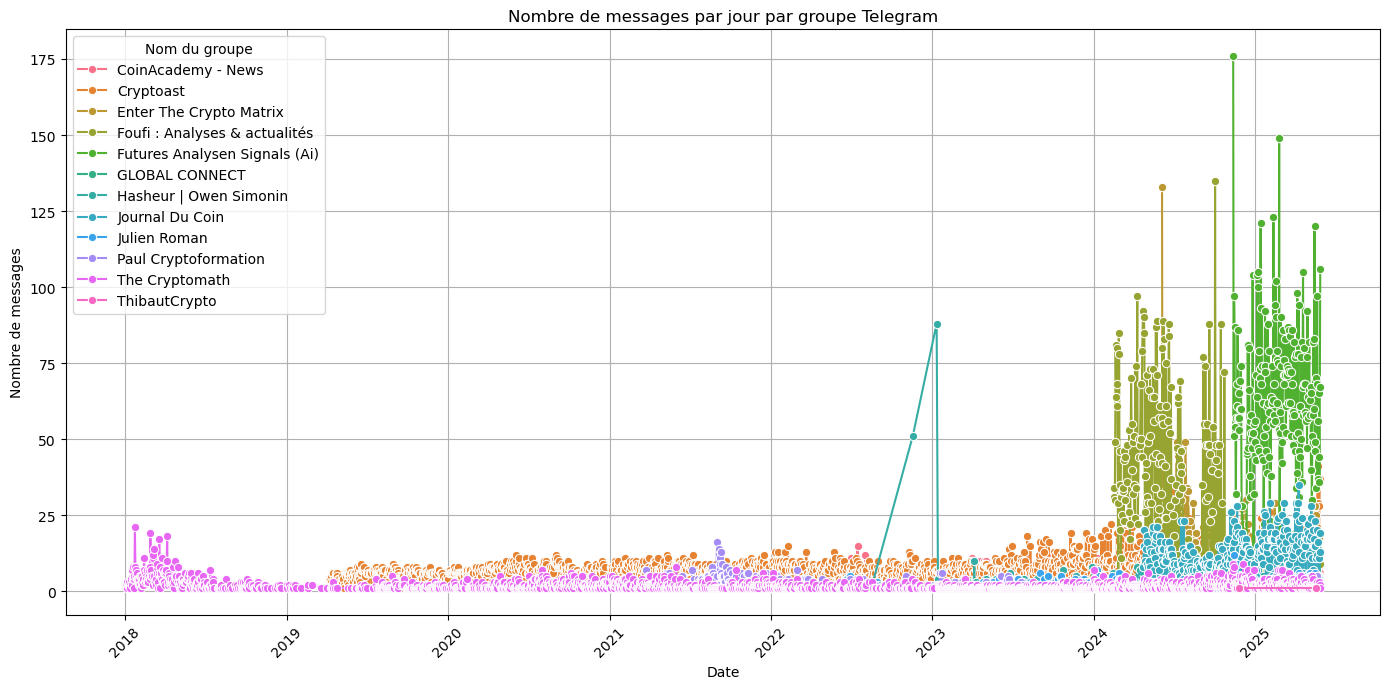

In [255]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Conversion de la date
df['date'] = pd.to_datetime(df['date'])

# Groupement par jour et par groupe
messages_par_jour = df.groupby(['group_name', df['date'].dt.date]).size().reset_index(name='n_messages')
messages_par_jour['date'] = pd.to_datetime(messages_par_jour['date'])

# Graphique
plt.figure(figsize=(14, 7))
sns.lineplot(data=messages_par_jour, x='date', y='n_messages', hue='group_name', marker='o')

plt.title("Nombre de messages par jour par groupe Telegram")
plt.xlabel("Date")
plt.ylabel("Nombre de messages")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Nom du groupe')
plt.tight_layout()

# Sauvegarde du graphique en tant qu'image PNG
plt.savefig("messages_par_jour.png", dpi=300)

# Affichage
plt.show()


Un graphique en courbe a été réalisé afin de visualiser le nombre de publications par jour et par groupe d’influenceurs.
On remarque que de 2018 jusqu’à début 2024, l’activité était relativement stable, avec en moyenne 7 publications par jour, principalement portées par quelques influenceurs déjà bien établis.

Cependant, à partir de 2024, une augmentation marquée de l’activité est observée. Cette hausse coïncide avec l’arrivée de nouveaux influenceurs très actifs, ce qui contribue à redynamiser la diffusion des contenus liés aux crypto-monnaies sur Telegram.
Parmi ces nouveaux influenceurs, on note que Journal Du Coin, Futures Analysen Signals (Ai), Foufi : Analyses & actualités et Julien Roman sont ceux qui publient désormais le plus de messages.

Un fait marquant a été relevé le 12 novembre 2024 :
Futures Analysen Signals (Ai) a atteint un pic de 175 publications en une seule journée. Ce pic correspond à un événement majeur sur le marché des cryptos :

Le Bitcoin a bondi de 9 % en 24 heures et de 30 % en une semaine, atteignant 89 000 dollars, tout près du seuil symbolique des 100 000 $. Ce franchissement de l’ATH (All-Time High) a généré un fort engouement, amplifié par la couverture massive des influenceurs.

Ce type d’événement montre à quel point les influenceurs récents peuvent jouer un rôle central dans la diffusion rapide de l’information, en relayant les évolutions majeures du marché en temps réel et en stimulant l’engagement de la communauté crypto.

In [258]:
import pandas as pd

# On suppose que messages_par_jour contient les colonnes : group_name, date, n_messages

# Pour chaque groupe, trouver le jour avec le nombre de messages maximal
max_messages_par_groupe = (
    messages_par_jour.loc[
        messages_par_jour.groupby('group_name')['n_messages'].idxmax()
    ]
    .sort_values(by='n_messages', ascending=False)
    .reset_index(drop=True)
)

print(max_messages_par_groupe)


                       group_name       date  n_messages
0   Futures Analysen Signals (Ai) 2024-11-12         176
1   Foufi : Analyses & actualités 2024-10-02         135
2         Enter The Crypto Matrix 2024-06-04         133
3          Hasheur | Owen Simonin 2023-01-11          88
4                       Cryptoast 2025-05-22          41
5                 Journal Du Coin 2025-04-09          35
6                  The Cryptomath 2018-01-23          21
7            Paul Cryptoformation 2021-09-01          16
8              CoinAcademy - News 2022-07-16          15
9                    Julien Roman 2024-11-14          12
10                 GLOBAL CONNECT 2025-05-06           8
11                  ThibautCrypto 2024-11-25           1


Un graphique en courbe a été réalisé pour visualiser le nombre de publications par jour et par groupe.
On observe que de 2018 à début 2024, l’activité restait relativement stable autour de 7 publications quotidiennes en moyenne, avec une prédominance de quelques groupes majeurs.
À partir de 2024, on constate une augmentation nette de l’activité, marquée par l’émergence de nouveaux groupes. Cela traduit une dynamisation du phénomène crypto sur Telegram, avec davantage d’interactions, de contenus, et d’acteurs impliqués.


**Les mensions**

plateforme
t.me             521
youtube.com      207
twitter.com      137
discord.gg        38
instagram.com     19
Name: count, dtype: int64


C:\Users\adjeg\AppData\Local\Temp\ipykernel_36920\3162723856.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plateformes.index, y=plateformes.values, palette='viridis')


Text(0.5, 1.0, "Fréquence des liens vers d'autres plateformes")

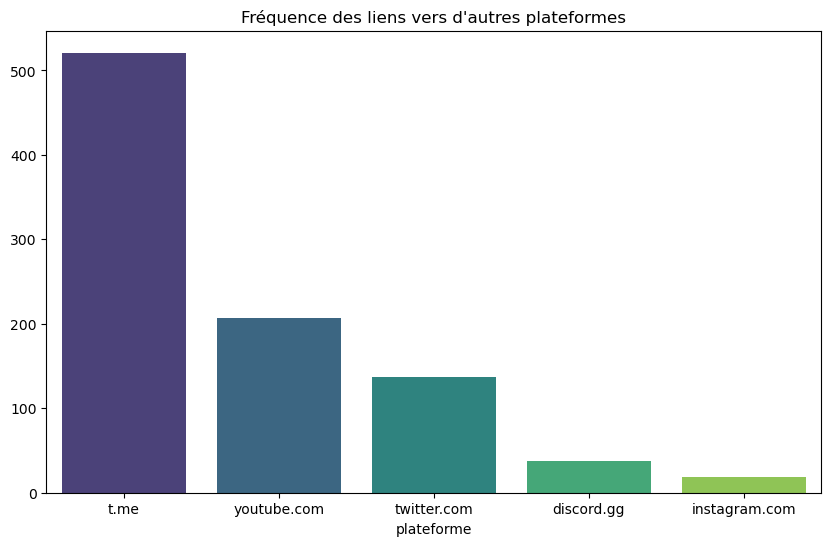

In [63]:
# Les liens vers d'autres plateformes
df['contient_lien'] = df['message'].str.contains('https?://', na=False)
df['plateforme'] = df['message'].str.extract(r'(t\.me|twitter\.com|youtube\.com|instagram\.com|discord\.gg)', expand=False)

plateformes = df['plateforme'].value_counts()
print(plateformes)

# Barplot avec seaborn
plt.figure(figsize=(10, 6)) 
sns.barplot(x=plateformes.index, y=plateformes.values, palette='viridis')
plt.title("Fréquence des liens vers d'autres plateformes")


Pour mieux comprendre comment les influenceurs participent à la diffusion du phénomène crypto, nous avons observé les plateformes mentionnées dans leurs publications Telegram. L’objectif est de voir où ils redirigent leur audience et quels réseaux sociaux ils mobilisent pour étendre leur influence.

Le barplot montre que :

Telegram (t.me) reste la plateforme la plus citée avec 521 mentions, ce qui confirme son rôle central comme espace de communication direct et communautaire pour les influenceurs crypto où il redirige leurs abonnées vers d'autres cannaux Telegram payant ou réservé à un cercle fermé.

YouTube arrive en deuxième position (207 mentions), signe que la vidéo est un format clé pour expliquer, former ou analyser l’évolution du marché.

Twitter est aussi très présent (137 mentions) : c’est un canal efficace pour réagir rapidement à l’actualité crypto, publier des threads, ou partager des graphiques.

Discord (38 mentions) est utilisé pour organiser des discussions plus ciblées avec des membres actifs de la communauté.

Enfin, Instagram est peu cité (19 mentions) mais reste un outil visuel utile pour toucher un public plus large et moins technique.

Le fait que les influenceurs mentionnent plusieurs plateformes montre qu’ils multiplient les points de contact avec leur audience. En combinant Telegram, YouTube, Twitter, etc., ils maximisent leur portée, atteignent différents profils d’utilisateurs, et rendent la crypto-monnaie plus accessible. Dans un contexte où la crypto reste un actif spéculatif, leur capacité à mobiliser ces canaux peut avoir un impact direct sur la perception du marché et l'engagement du public. Plus ils sont présents sur plusieurs réseaux, plus ils contribuent à la vulgarisation et à l’adhésion massive au phénomène crypto.

In [64]:
# Détection des liens et des plateformes dans les messages par groupe
df['contient_lien'] = df['message'].str.contains(r'https?://', na=False)
df['plateforme'] = df['message'].str.extract(r'(t\.me|twitter\.com|youtube\.com|instagram\.com|discord\.gg)', expand=False)

# Comptage du nombre de messages contenant un lien par groupe
liens_par_groupe = df.groupby('group_name')['contient_lien'].sum().reset_index(name='nb_messages_avec_lien')

# Comptage du total de messages par groupe
total_par_groupe = df.groupby('group_name').size().reset_index(name='nb_total_messages')

# Pourcentage de messages contenant un lien par groupe
analyse_liens = pd.merge(liens_par_groupe, total_par_groupe, on='group_name')
analyse_liens['%_messages_avec_lien'] = 100 * analyse_liens['nb_messages_avec_lien'] / analyse_liens['nb_total_messages']

# Nombre de messages par plateforme et par groupe
plateformes_par_groupe = df.groupby(['group_name', 'plateforme']).size().reset_index(name='nb_messages_plateforme')
plateformes_par_groupe = plateformes_par_groupe.dropna(subset=['plateforme'])

# Affichage
print("=== Pourcentage de messages avec lien par groupe ===")
print(analyse_liens.sort_values('%_messages_avec_lien', ascending=False))

print("\n=== Répartition des plateformes par groupe ===")
plateformes_par_groupe.sort_values(['group_name', 'nb_messages_plateforme'], ascending=[True, False]) 


=== Pourcentage de messages avec lien par groupe ===
                       group_name  nb_messages_avec_lien  nb_total_messages  \
0              CoinAcademy - News                   5103               5108   
1                       Cryptoast                  13875              15607   
5                  GLOBAL CONNECT                      8                 27   
9            Paul Cryptoformation                    460               1579   
8                    Julien Roman                    312               1393   
10                 The Cryptomath                    341               3884   
3   Foufi : Analyses & actualités                    779               9365   
6          Hasheur | Owen Simonin                    102               1278   
2         Enter The Crypto Matrix                     72               2472   
7                 Journal Du Coin                      5               3939   
4   Futures Analysen Signals (Ai)                      0              12121   

,group_name,plateforme,nb_messages_plateforme
4,Cryptoast,youtube.com,60
3,Cryptoast,twitter.com,17
0,Cryptoast,discord.gg,5
2,Cryptoast,t.me,3
1,Cryptoast,instagram.com,2
5,Enter The Crypto Matrix,t.me,53
6,Enter The Crypto Matrix,youtube.com,1
7,Foufi : Analyses & actualités,t.me,425
8,Foufi : Analyses & actualités,youtube.com,48
9,GLOBAL CONNECT,t.me,6


Objectifs d’analyse et approches

**2. Pourquoi les gens s’intéressent à la crypto ?**

Méthodes :
Analyse de contenu (message) :

Identifier les mots-clés fréquents : gains, opportunités, liberté financière, NFT, Web3, blockchain, investissement, bull run...

Utiliser une analyse de sentiment (VADER ou TextBlob) pour détecter si les messages sont positifs (ex : gains, avenir prometteur) ou négatifs (ex : crash, peur).

Repérer des thèmes récurrents à travers une analyse thématique ou LDA (topic modeling).

Indicateurs possibles :
Fréquence des messages contenant des termes comme Bitcoin, gagner, investir, ETF, liberté.

Volume de messages autour d’événements spécifiques (ex : bull market, régulation).

C:\Users\adjeg\AppData\Local\Temp\ipykernel_36920\3324708825.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\adjeg\AppData\Local\Temp\ipykernel_36920\3324708825.py:36: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from current font.

C:\Users\adjeg\AppData\Local\Temp\ipykernel_36920\3324708825.py:39: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from current font.

C:\Users\adjeg\conda_new\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from current font.



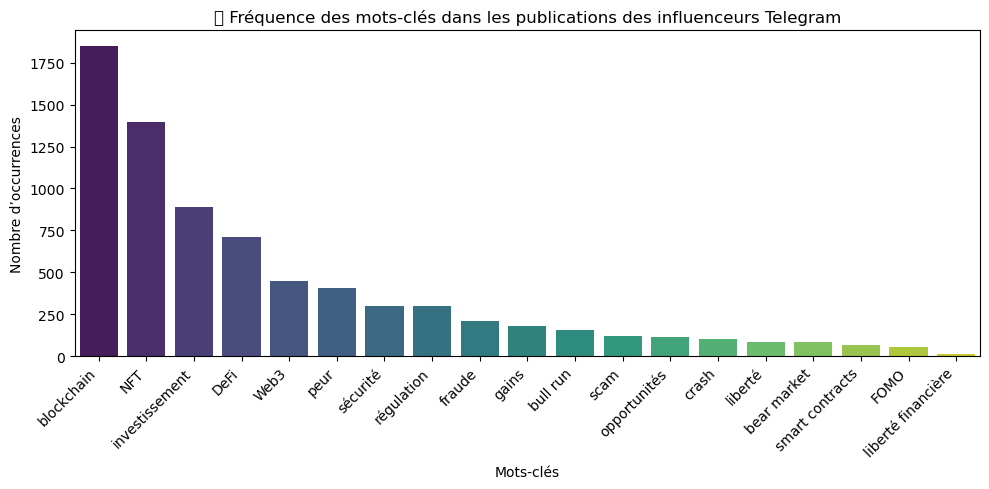

In [275]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Liste enrichie de mots-clés
keywords = [
    'gains', 'opportunités', 'liberté', 'liberté financière', 'NFT', 'Web3', 
    'blockchain', 'investissement', 'bull run', 'crash', 'peur', 'régulation',
    'DeFi', 'FOMO', 'bear market', 'smart contracts', 'fraude', 
    'sécurité', 'scam'
]

# Mise en minuscule pour éviter les problèmes de casse
df['message'] = df['message'].astype(str).str.lower()

# Création des colonnes booléennes pour chaque mot-clé
for kw in keywords:
    col_name = f'contains_{kw.replace(" ", "_")}'
    df[col_name] = df['message'].str.contains(kw.lower(), na=False)

# Calcul de la fréquence des mots-clés
freq_keywords = df[[col for col in df.columns if col.startswith('contains_')]].sum().sort_values(ascending=False)

# Préparation des données pour le graphique
freq_df = freq_keywords.reset_index()
freq_df.columns = ['mot_clé', 'fréquence']
freq_df['mot_clé'] = freq_df['mot_clé'].str.replace('contains_', '', regex=False).str.replace('_', ' ', regex=False)

# Création du barplot (graphique plus petit pour PDF ou support écrit)
plt.figure(figsize=(10, 5))  # Taille réduite
sns.barplot(data=freq_df, x='mot_clé', y='fréquence', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('📊 Fréquence des mots-clés dans les publications des influenceurs Telegram')
plt.xlabel('Mots-clés')
plt.ylabel('Nombre d’occurrences')
plt.tight_layout()

# Sauvegarde du graphique avant affichage
plt.savefig("themes_abordes.png", dpi=300, bbox_inches='tight')
plt.show()


C:\Users\adjeg\AppData\Local\Temp\ipykernel_36920\3584855717.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\adjeg\AppData\Local\Temp\ipykernel_36920\3584855717.py:36: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from current font.

C:\Users\adjeg\conda_new\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from current font.



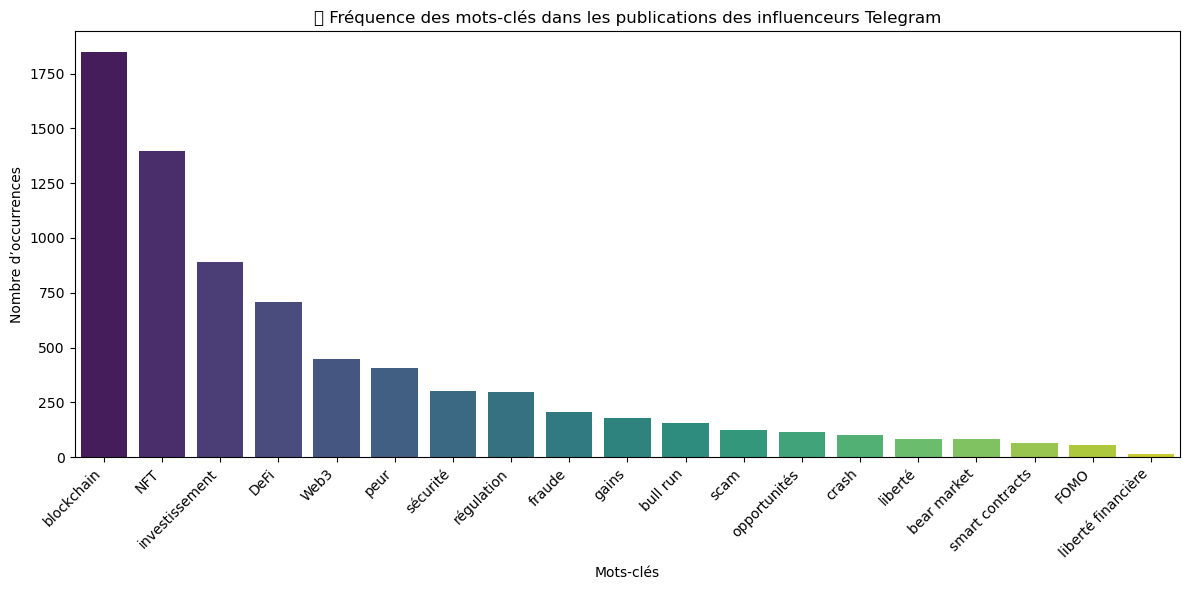

<Figure size 640x480 with 0 Axes>

Dans le cadre de notre analyse sur le rôle des influenceurs dans le phénomène crypto, nous avons étudié les thématiques abordées dans leurs publications sur Telegram à partir d’un ensemble de 56 775 messages. En extrayant des mots-clés représentatifs ses discours crypto (comme blockchain, investissement, NFT, etc.), nous avons mesuré leur fréquence d’apparition afin d’identifier les sujets les plus récurrents.
L’analyse du barplot montre que les influenceurs abordent prioritairement des sujets technologiques et financiers. Le terme "blockchain" est le plus présent (1 850 occurrences), soulignant l’importance de la technologie sous-jacente dans leur discours. Le mot "NFT" arrive en deuxième position (1 395), ce qui reflète l’engouement massif autour de ces actifs numériques uniques, surtout depuis 2021.

On retrouve ensuite des notions directement liées à l’investissement : investissement (891), DeFi (709) et Web3 (449), ce qui montre que les influenceurs jouent un rôle clé dans la vulgarisation des opportunités financières et des nouvelles tendances du Web décentralisé.

Des thématiques plus sensibles comme la peur (408), la sécurité (302), la régulation (298) ou encore la fraude (207) sont également présentes. Cela indique que les influenceurs ne se contentent pas de vendre du rêve : ils abordent aussi les risques liés à l’écosystème crypto, renforçant leur rôle d’alerte ou d’accompagnateur.

Enfin, les termes liés à l'émotion ou à la spéculation tels que gains, bull run, scam, FOMO ou crash apparaissent moins fréquemment, mais restent significatifs. Ils témoignent d’un discours souvent rythmé par les variations de marché et l’excitation des phases de hausse.

Les influenceurs abordent des thématiques variées, combinant pédagogie technologique, opportunités d’investissement, et mise en garde sur les risques. Ils contribuent ainsi à structurer l'information autour de la cryptomonaie, en jouant à la fois le rôle de vulgarisateur, de promoteur pour leur communauté.

Sentiment par mot clé 

In [270]:

analyzer = SentimentIntensityAnalyzer()

# Score de sentiment
df['sentiment_score'] = df['message'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

# Sentiment moyen pour chaque mot-clé
for kw in keywords:
    col = f'contains_{kw.replace(" ", "_")}'
    mean_sent = df[df[col]]['sentiment_score'].mean()
    print(f"🧠 Sentiment moyen pour '{kw}': {mean_sent:.2f}")


🧠 Sentiment moyen pour 'gains': 0.47
🧠 Sentiment moyen pour 'opportunités': 0.09
🧠 Sentiment moyen pour 'liberté': 0.07
🧠 Sentiment moyen pour 'liberté financière': 0.27
🧠 Sentiment moyen pour 'NFT': 0.06
🧠 Sentiment moyen pour 'Web3': 0.10
🧠 Sentiment moyen pour 'blockchain': 0.08
🧠 Sentiment moyen pour 'investissement': 0.16
🧠 Sentiment moyen pour 'bull run': 0.16
🧠 Sentiment moyen pour 'crash': -0.31
🧠 Sentiment moyen pour 'peur': 0.07
🧠 Sentiment moyen pour 'régulation': 0.03
🧠 Sentiment moyen pour 'DeFi': 0.09
🧠 Sentiment moyen pour 'FOMO': 0.13
🧠 Sentiment moyen pour 'bear market': 0.08
🧠 Sentiment moyen pour 'smart contracts': 0.41
🧠 Sentiment moyen pour 'fraude': 0.03
🧠 Sentiment moyen pour 'sécurité': 0.12
🧠 Sentiment moyen pour 'scam': -0.35


**calculer le sentiment par message par jour**

In [83]:
analyzer = SentimentIntensityAnalyzer()

# Calcul du score de sentiment pour chaque message
df['sentiment_score'] = df['message'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

# Attribution de l'étiquette de sentiment
def label_sentiment(score):
    if score >= 0.05:
        return 'positif'
    elif score <= -0.05:
        return 'négatif'
    else:
        return 'neutre'

df['sentiment_label'] = df['sentiment_score'].apply(label_sentiment)

# Extraire l'année à partir de la colonne "date"
df['year'] = pd.to_datetime(df['date']).dt.year

# Agrégation par année et type de sentiment
sentiment_annual = df.groupby(['year', 'sentiment_label']).size().unstack(fill_value=0)
sentiment_annual = sentiment_annual.sort_index()
sentiment_annual 


sentiment_label,neutre,négatif,positif
year,,,
2018,655,111,89
2019,1194,71,131
2020,2098,156,221
2021,2770,267,617
2022,3322,315,442
2023,4263,477,770
2024,15521,2209,3676
2025,5766,3867,7767


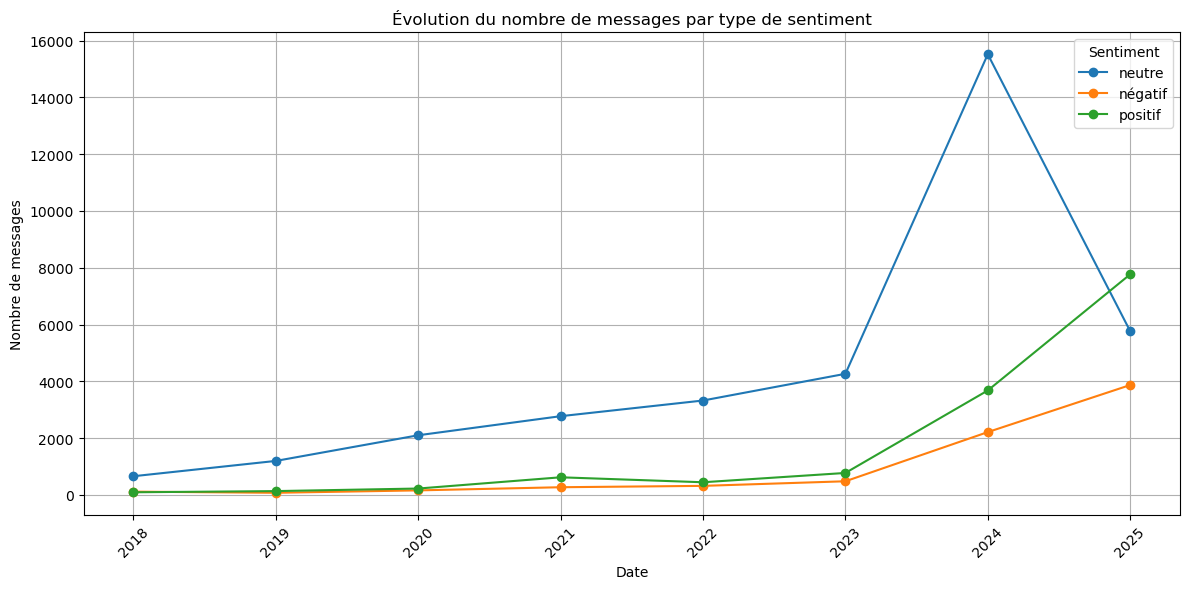

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sentiment_annual.plot(kind='line', marker='o', ax=plt.gca())

plt.title("Évolution du nombre de messages par type de sentiment")
plt.xlabel("Date")
plt.ylabel("Nombre de messages")
plt.grid(True)
plt.legend(title='Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**3. Quelles sont leurs pratiques ?**

Méthodes :
Repérage de certaines formules linguistiques : 📢 "Alerte", 💰 "projet prometteur", 🔥 "à ne pas manquer".

Présence de médias partagés (si tu ajoutes plus tard la variable media_type) → Photos, vidéos, liens vers Twitter ou Telegram.

Sujets : trading, NFT, airdrops, wallets, nouvelles cryptos...

Indicateurs :
Part de messages qui ont des termes typiques du FOMO (fear of missing out).

Analyse de la longueur des messages → info courte ou contenu explicatif ?

Analyse de répétition ou redondance (ex : pub pour une ICO sur plusieurs jours).

En ce qui concerne la question : Quelles sont leurs pratiques. Nous allons partir sur la base des méssage scrper sur Telegram pour analyser leurs différentes pratiques. Le but est d'analyser ces pratiques pour voir quelles sont les pratiques ou methodes, les formations, les vidéos sponsoriéess, pump & dump, lien d'affiliation, promotion de services, des projets bidons derrière la crypto, trading avec effet de leviier, les offres de partenariats offre inadaptée à l'audience. Le but est d'allerté sur le fonctionnement de la crrytspsère. 

On va aller grace à l'anlyse des messages publés sur ces différentes comptes chercher ls informations suivantes pour répondre à : quelles sont les pratiques des cryptos iinfluenceurs ? 

Méthodes : Repérage de certaines formules linguistiques : 📢 "Alerte", 💰 "projet prometteur", 🔥 "à ne pas manquer".

Présence de médias partagés (si tu ajoutes plus tard la variable media_type) → Photos, vidéos, liens vers Twitter ou Telegram.

Sujets : trading, NFT, airdrops, wallets, nouvelles cryptos...

Indicateurs : Part de messages qui ont des termes typiques du FOMO (fear of missing out).

Analyse de la longueur des messages → info courte ou contenu explicatif ?

Analyse de répétition ou redondance (ex : pub pour une ICO sur plusieurs jours).

Méthodologie – Identifier les pratiques des crypto-influenceurs
Pour répondre à la question « Quelles sont les pratiques des influenceurs dans le domaine de la cryptomonnaie ? », nous nous appuyons sur les messages collectés sur Telegram. Ces messages ont été scrappés à partir de 12 comptes d’influenceurs spécialisés dans la crypto.

L’objectif ici est de comprendre les méthodes et stratégies qu’ils utilisent dans leurs publications pour attirer l’attention ou promouvoir certains projets. En étudiant leur manière de communiquer, on veut mettre en évidence :

Les techniques de promotion (vidéos sponsorisées, liens d’affiliation),

Les publications douteuses (pump & dump, projets peu fiables),

Les discours poussant au trading à haut risque (effet de levier),

Les messages orientés vers le FOMO (Fear of Missing Out),

Les offres mal ciblées ou inadaptées au public.

Comment on va procéder :
1. Analyse du contenu des messages
On va lire et analyser les messages en repérant certains mots ou expressions qui peuvent indiquer une intention commerciale ou une stratégie d’influence, comme :

📢 « Alerte »,

💰 « projet prometteur »,

🔥 « à ne pas manquer »,

« Gagne vite », « Offre limitée », etc.

Ces expressions attirent souvent l’attention et créent un sentiment d’urgence.

2. Présence de contenus multimédias
Grâce à la variable media_type, on va vérifier si les messages contiennent :

Des photos,

Des vidéos (parfois sponsorisées),

Des liens vers d'autres plateformes (Twitter, Telegram, YouTube...).

Cela nous aide à voir s’il y a une stratégie de communication plus visuelle ou externe.

3. Thèmes abordés
On va classer les messages selon les sujets évoqués :

Trading,

NFT,

Airdrops,

Wallets,

Lancements de nouvelles cryptos, etc.

Cela permet de savoir sur quoi ces influenceurs se concentrent le plus.

4. Analyse du FOMO
On va chercher les messages qui utilisent des termes liés au FOMO, pour savoir quelle part de leurs publications pousse à agir rapidement, sans réflexion.

5. Longueur des messages
Une analyse de la taille des messages nous permettra de savoir s’ils donnent juste une info courte (souvent pour vendre ou alerter) ou s’ils expliquent vraiment les projets.

6. Répétitions et campagnes
Enfin, on va repérer les messages répétés plusieurs jours de suite, surtout quand ils parlent de la même offre ou du même projet (ex. pub pour une ICO). Cela montre une stratégie de communication continue.

En combinant toutes ces observations, nous pourrons dresser un portrait détaillé des pratiques des influenceurs crypto, et voir dans quelle mesure certaines d’entre elles peuvent être problématiques ou trompeuses. Cette analyse servira à mieux comprendre comment fonctionne la cryptosphère et à alerter sur certains risques pour les utilisateurs.

In [202]:
# Détection de formules typiques FOMO : Repérage de mots-clés comme : "🔥", "🚨", "ALERTE", "à ne pas manquer", etc.
import re

# Liste des expressions FOMO typiques
fomo_keywords = [
    r"🔥", r"🚨", r"📢", r"📅", r"🆕", r"💸 ", r"🚨", "r🚨", r"👇", r"🗞️", r"📈", r"📊", r"\balerte\b", r"\bà ne pas manquer\b", r"\bprojet prometteur\b", 
    r"\bfoncez\b", r"\bgrosse opportunité\b", r"\bfomo\b", r"\bdernier moment\b", r"\bRallye haussier\b"
]

# Création d'une colonne "is_fomo"
pattern = re.compile("|".join(fomo_keywords), flags=re.IGNORECASE)
df["is_fomo"] = df["message"].fillna("").apply(lambda x: bool(pattern.search(x)))

# Pourcentage de messages FOMO
fomo_ratio = df["is_fomo"].mean()
print(f"Part de messages FOMO : {fomo_ratio:.2%}")


Part de messages FOMO : 24.41%


C:\Users\adjeg\AppData\Local\Temp\ipykernel_36920\3496909204.py:11: UserWarning:

Glyph 128226 (\N{PUBLIC ADDRESS LOUDSPEAKER}) missing from current font.

C:\Users\adjeg\AppData\Local\Temp\ipykernel_36920\3496909204.py:12: UserWarning:

Glyph 128226 (\N{PUBLIC ADDRESS LOUDSPEAKER}) missing from current font.

C:\Users\adjeg\conda_new\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128226 (\N{PUBLIC ADDRESS LOUDSPEAKER}) missing from current font.



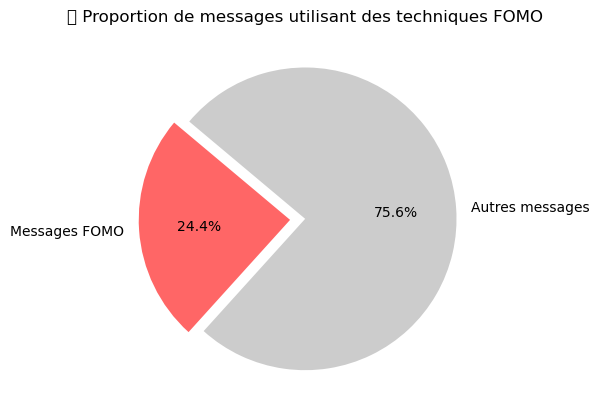

In [277]:
import matplotlib.pyplot as plt

labels = ['Messages FOMO', 'Autres messages']
sizes = [df["is_fomo"].sum(), len(df) - df["is_fomo"].sum()]
colors = ['#ff6666', '#cccccc']
explode = (0.1, 0)

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=explode)
plt.title('📢 Proportion de messages utilisant des techniques FOMO')
plt.tight_layout()
plt.savefig("fomo_piechart.png", dpi=300)
plt.show()


Le diagramme circulaire, montre qu’un quart des messages postés par les influenceurs cherchent à provoquer une réaction émotionnelle immédiate, souvent sans recul, en utilisant des symboles visuels forts (🔥, 🚨) ou des formulations alarmantes ("à ne pas manquer", "projet prometteur", "alerte", etc.).

Ce type de contenu crée une pression psychologique sur les abonnés, les incitant à investir ou suivre un projet sans analyse approfondie, ce qui est typique des pratiques de manipulation émotionnelle en crypto.

Cela peut représenter un risque pour les utilisateurs novices, surtout dans un secteur aussi spéculatif et volatil.

In [204]:
# Compter les types de médias partagés
media_stats = df["media_type"].value_counts(dropna=False)
print(media_stats)


media_type
MessageMediaWebPage     19568
None                    18992
MessageMediaPhoto       17042
MessageMediaDocument     1030
MessageMediaPoll          143
Name: count, dtype: int64


In [218]:
# Analyse thématique par mot-clé :Détection des grands thèmes : "trading", "NFT", "wallet", "airdrop", etc.

topics = {
    "trading": r"\btrade|trading|positions|leveraged\b",
    "nft": r"\bnft\b",
    "airdrop": r"\bairdrop\b",
    "wallet": r"\bwallet|metamask|ledger|cold storage\b",
    "new_crypto": r"\btoken\b|\blisté\b|\blisting\b|\bid\b"
}

# Ajouter une colonne par sujet
for topic, regex in topics.items():
    df[f"is_{topic}"] = df["message"].fillna("").str.contains(regex, case=False, regex=True)

# Nombre de messages par sujet
topic_counts = df[[f"is_{k}" for k in topics]].sum()
print(topic_counts)


is_trading       4937
is_nft           1045
is_airdrop        442
is_wallet         947
is_new_crypto     850
dtype: int64


count    56775.000000
mean        24.543320
std         40.698851
min          0.000000
25%         11.000000
50%         14.000000
75%         20.000000
max        690.000000
Name: message_length_words, dtype: float64


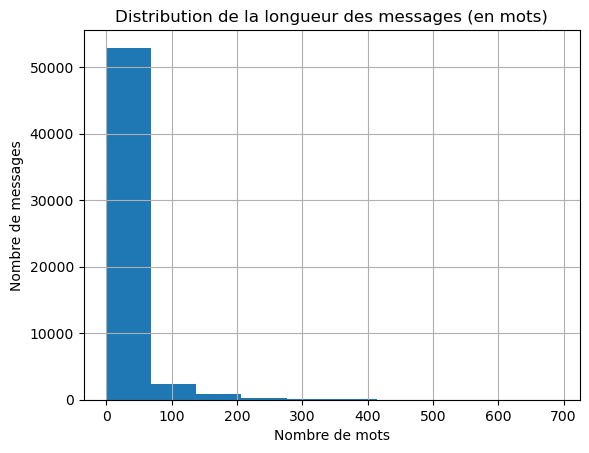

In [300]:
# Analyse de longueur des messages
# Longueur en mots
df["message_length_words"] = df["message"].fillna("").apply(lambda x: len(x.split()))

# Statistiques descriptives
print(df["message_length_words"].describe())

# Visualisation (optionnel)
import matplotlib.pyplot as plt
df["message_length_words"].hist()
plt.title("Distribution de la longueur des messages (en mots)")
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre de messages")
plt.show()




In [286]:
df["message_length_words"].describe()

count    56775.000000
mean        24.543320
std         40.698851
min          0.000000
25%         11.000000
50%         14.000000
75%         20.000000
max        690.000000
Name: message_length_words, dtype: float64

Pour mieux comprendre les pratiques de communication des influenceurs crypto, j’ai étudié la longueur de leurs messages, mesurée en nombre de mots. Voici les statistiques obtenues :
Cette distribution montre clairement que la majorité des messages sont très courts. Plus de la moitié font moins de 14 mots, ce qui est très peu pour expliquer en détail un projet de cryptomonnaie.

Cela laisse penser que :

Les influenceurs cherchent à être directs et percutants.

Beaucoup de messages sont là pour attirer l’attention rapidement, parfois en créant un sentiment d’urgence. En revanche, il existe quelques messages très longs (jusqu’à 690 mots), ce qui montre que certains prennent aussi le temps d’expliquer certains projets ou de faire des annonces plus détaillées.

Cette analyse montre que les influenceurs crypto utilisent surtout des messages courts pour frapper vite et fort. Cela correspond à une stratégie de communication typique des réseaux sociaux, où l’attention est limitée. Ces messages sont souvent utilisés pour vendre, alerter ou inciter à cliquer rapidement, plutôt que pour informer en profondeur.

In [240]:
# Analyse de redondance / répétition
# On cherche par exemple les mots les plus répétés sur plusieurs jours, ou des messages très similaires.

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Nettoyage simple
df["clean_message"] = df["message"].fillna("").str.lower()

# TF-IDF pour mesurer la similarité des messages
tfidf = TfidfVectorizer(stop_words="french")
tfidf_matrix = tfidf.fit_transform(df["clean_message"])

# Calcul des similarités (optionnel : lourd si beaucoup de messages)
similarities = cosine_similarity(tfidf_matrix)

# Repérer les messages très similaires (redondants)
import numpy as np
threshold = 0.95  # très proches
redundant_pairs = np.argwhere((similarities > threshold) & (similarities < 1.0))

# Affichage
print(f"Nombre de paires de messages très similaires : {len(redundant_pairs)}")


InvalidParameterError: The 'stop_words' parameter of TfidfVectorizer must be a str among {'english'}, an instance of 'list' or None. Got 'french' instead.


**4. Comment les influenceurs mobilisent les différents réseaux sociaux ?**

Il te faudrait idéalement les champs username, media_path, ou des URLs dans les messages.

Méthodes :
Rechercher dans les messages les liens vers d'autres plateformes : https://t.me, twitter.com, youtube.com, etc.

Mesurer la fréquence de renvois croisés entre plateformes.

Indicateurs :
Nombre de messages contenant un lien externe.

Plateformes mentionnées le plus souvent.

Type de contenu relayé (vidéo YouTube ? post X ? Telegram ?).**

In [242]:
# Fonction pour extraire les URLs : Détection des URLs dans les messages
url_pattern = r'(https?://[^\s]+)'
df["urls"] = df["message"].fillna("").apply(lambda x: re.findall(url_pattern, x))

# Messages avec au moins un lien
df["has_link"] = df["urls"].apply(lambda x: len(x) > 0)

# Nombre de messages contenant un lien externe
nb_with_links = df["has_link"].sum()
print(f"Nombre de messages contenant au moins un lien : {nb_with_links}")


Nombre de messages contenant au moins un lien : 21057


In [28]:
# Fréquence de renvois croisés par plateforme
# Plateformes cibles à analyser
platforms = {
    "Telegram": r"t\.me",
    "Twitter": r"twitter\.com|x\.com",
    "YouTube": r"youtube\.com|youtu\.be",
    "Instagram": r"instagram\.com",
    "TikTok": r"tiktok\.com",
    "Medium": r"medium\.com",
    "Discord": r"discord\.gg",
    "LinkedIn": r"linkedin\.com",
    "SitePerso": r"\.xyz|\.io|\.com|\.net|\.org"  # à affiner si besoin
}

# Création de colonnes booléennes pour chaque plateforme
for name, pattern in platforms.items():
    df[f"has_{name.lower()}"] = df["urls"].apply(
        lambda urls: any(re.search(pattern, url) for url in urls)
    )

# Comptage
platform_mentions = {name: df[f"has_{name.lower()}"].sum() for name in platforms}
print("Nombre de mentions par plateforme :")
for k, v in platform_mentions.items():
    print(f"{k}: {v}")


Nombre de mentions par plateforme :
Telegram: 533
Twitter: 355
YouTube: 1542
Instagram: 35
TikTok: 9
Medium: 18
Discord: 86
LinkedIn: 5
SitePerso: 884


In [34]:
from collections import Counter  # ← à ajouter impérativement

# Type de contenu relayé (vidéos, tweets, etc.) 
def classify_url(url):
    if "youtube" in url or "youtu.be" in url:
        return "YouTube video"
    elif "twitter.com" in url or "x.com" in url:
        return "Tweet/X post"
    elif "t.me" in url:
        return "Telegram Channel/Post"
    elif "instagram.com" in url:
        return "Instagram Post"
    elif "tiktok.com" in url:
        return "TikTok Video"
    elif "medium.com" in url:
        return "Medium article"
    else:
        return "Other"

# Appliquer la classification sur toutes les URLs
url_types = []
for url_list in df["urls"]:
    for url in url_list:
        url_types.append(classify_url(url.lower()))

# Statistiques
content_type_counts = Counter(url_types)
print("\nTypes de contenus relayés :")
for k, v in content_type_counts.items():
    print(f"{k}: {v}")



Types de contenus relayés :
Other: 20166
YouTube video: 1563
Tweet/X post: 384
Instagram Post: 27
TikTok Video: 6
Telegram Channel/Post: 591
Medium article: 18


In [ ]:
print("\n--- RÉSUMÉ ---")
print(f"Total de messages analysés : {len(df)}")
print(f"Messages avec lien externe : {df['has_link'].sum()} ({df['has_link'].mean():.2%})")
print(f"Plateforme la plus mentionnée : {max(platform_mentions, key=platform_mentions.get)}")
print(f"Type de contenu le plus relayé : {content_type_counts.most_common(1)[0][0]}")


--- RÉSUMÉ ---
Total de messages analysés : 56775
Messages avec lien externe : 21057 (37.09%)
Plateforme la plus mentionnée : YouTube
Type de contenu le plus relayé : Other


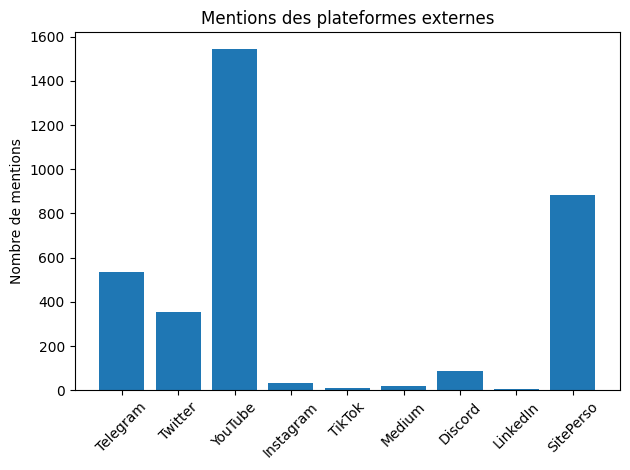

In [36]:
import matplotlib.pyplot as plt

# Mentions par plateforme
plt.bar(platform_mentions.keys(), platform_mentions.values())
plt.title("Mentions des plateformes externes")
plt.ylabel("Nombre de mentions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**5. Faire la même analyse par influenceur (group_name)**

In [37]:
from collections import defaultdict, Counter

# Fonction pour classifier les URLs
def classify_url(url):
    url = url.lower()
    if "youtube" in url or "youtu.be" in url:
        return "YouTube video"
    elif "twitter.com" in url or "x.com" in url:
        return "Tweet/X post"
    elif "t.me" in url:
        return "Telegram Channel/Post"
    elif "instagram.com" in url:
        return "Instagram Post"
    elif "tiktok.com" in url:
        return "TikTok Video"
    elif "medium.com" in url:
        return "Medium article"
    else:
        return "Other"

# Dictionnaire {group_name: Counter({type: count})}
group_platform_stats = defaultdict(Counter)

# Parcourir les lignes
for _, row in df.iterrows():
    group = row["group_name"]
    urls = row["urls"]
    
    for url in urls:
        content_type = classify_url(url)
        group_platform_stats[group][content_type] += 1

# Afficher les résultats par groupe
for group, counter in group_platform_stats.items():
    print(f"\n📢 Groupe : {group}")
    for content_type, count in counter.items():
        print(f"  - {content_type} : {count}")



📢 Groupe : Cryptoast
  - Other : 13616
  - YouTube video : 304
  - Tweet/X post : 51
  - Instagram Post : 5
  - TikTok Video : 2
  - Telegram Channel/Post : 2

📢 Groupe : Journal Du Coin
  - Other : 5

📢 Groupe : Hasheur | Owen Simonin
  - Other : 80
  - YouTube video : 39
  - Telegram Channel/Post : 3
  - Tweet/X post : 2

📢 Groupe : CoinAcademy - News
  - Other : 5100
  - YouTube video : 3

📢 Groupe : Foufi : Analyses & actualités
  - YouTube video : 731
  - Telegram Channel/Post : 471
  - Other : 688
  - Tweet/X post : 150
  - Instagram Post : 12
  - TikTok Video : 2

📢 Groupe : Julien Roman
  - Other : 128
  - YouTube video : 178
  - Instagram Post : 3
  - Tweet/X post : 6
  - TikTok Video : 2

📢 Groupe : The Cryptomath
  - Tweet/X post : 148
  - Other : 212
  - Telegram Channel/Post : 37
  - YouTube video : 4
  - Medium article : 9
  - Instagram Post : 7

📢 Groupe : Paul Cryptoformation
  - YouTube video : 299
  - Other : 138
  - Telegram Channel/Post : 12
  - Tweet/X post : 27
 

In [238]:
Ce projet s’inscrit dans le cadre d’une étude sur l’analyse des réseaux sociaux d’influenceurs cryptos, dans le but de comprendre pourquoi les gens s’intéressent de plus en plus aux cryptomonnaies. L’hypothèse principale est que cet intérêt pourrait s’expliquer, en partie, par les performances financières des cryptos comparées à celles des actifs traditionnels, mais aussi par la perte de valeur de l’épargne classique liée à l’inflation et aussi la recherche du gain facile rechercher par certain jeunes à qui on fait croire qu'on peut s'enrichir facilement et rapidement grace aux cryptos.

Pour appuyer cette réflexion, nous avons décidé de comparer les performances des cryptomonnaies (Bitcoin et Ethereum) à plusieurs actifs financiers bien établis comme les indices boursiers (S&P 500, NASDAQ 100, CAC 40), l’or et le pétrole. Voici les actifs analysés :







Nom de l’actif

Code Yahoo Finance

Interprétation / Signification

S&P 500

^GSPC

Indice boursier regroupant les 500 plus grandes entreprises cotées aux États-Unis. Il sert de baromètre de la santé économique américaine et des marchés actions US.

NASDAQ 100

^NDX

Indice technologique regroupant les 100 plus grandes entreprises non financières cotées sur le NASDAQ, comme Apple, Microsoft ou Amazon.

CAC 40

^FCHI

Principal indice boursier français, composé des 40 plus grandes entreprises cotées à la Bourse de Paris.

Bitcoin

BTC-USD

Première et principale cryptomonnaie. Considérée comme une réserve de valeur numérique et un actif spéculatif.

Ethereum

ETH-USD

Deuxième cryptomonnaie en capitalisation. C’est aussi une plateforme de contrats intelligents utilisée dans la finance décentralisée (DeFi) et les NFT.

Or (Gold)

GC=F

Métal précieux historique considéré comme une valeur refuge en période d’incertitude économique ou d’inflation.

Pétrole (Brent)

BZ=F

Référence mondiale pour le prix du pétrole brut. Son évolution influence fortement l’économie mondiale et les prix à la consommation.





Les données sont collectées à l’aide de la bibliothèque Python yfinance, qui permet de récupérer gratuitement les historiques de prix depuis Yahoo Finance. Une fois les données récupérées, nous procédons à plusieurs types d’analyses :

Analyse des performances sur une période donnée (rendement, volatilité, évolution du prix)
Comparaison avec l’inflation pour voir si les cryptos offrent une meilleure protection du pouvoir d’achat que les produits d’épargne traditionnels comme le Livret A ou l’assurance-vie
Visualisation des résultats avec des outils comme matplotlib, seaborn ou plotly pour une lecture claire et intuitive

Cette approche nous permettra d’évaluer dans quelle mesure la performance financière des cryptos pourrait justifier l’intérêt qu’elles suscitent sur les réseaux sociaux. Elle servira aussi de base pour comprendre comment les influenceurs utilisent cet argument de performance dans leurs contenus afin de capter l’attention de leur audience.

SyntaxError: invalid character '’' (U+2019) (3344427861.py, line 1)